#Gender Classification
- Dataset: Gender Classification Dataset (Kaggle)
- Samples: 5,001
- Target: gender (Male / Female)

#Models used
- HistGradientBoostingClassifier
- LogisticRegression

#HyperTuning used per model
- HistGradientBoostingClassifier
  - learning_rate
  - max_depth
  - max_iter
- LogisticRegression
  - c

#Ttransformation used
- StanderScaler
  - numeric feature
#--------------------------------------------------------


# Load and Inspect Data

In [1]:
import pandas as pd
import kagglehub

# Download dataset
path = kagglehub.dataset_download("elakiricoder/gender-classification-dataset")
path = path + "/gender_classification_v7.csv"

data = pd.read_csv(path)

data.head()


100%|██████████| 19.0k/19.0k [00:00<00:00, 4.98MB/s]

Extracting files...


,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [2]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [3]:
data["gender"].value_counts()


,count
gender,
Female,2501
Male,2500


# data quick summary
- No missing values
- Features are Mix of numerical + binary

## we need to
- apply StandardScaler preprocessing on numrical data
- keep bin as it is

#------------------------------------------------------------------------------
# **Split Data**
###Prepare Features and Target

In [4]:
X = data.drop(columns="gender")
y = data["gender"]


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler




---


#Make a Preprocessing Pipeline
###prepare transformers for **numeric** features

In [6]:
numeric_features = ["forehead_width_cm", "forehead_height_cm"]
binary_features = [
    "long_hair",
    "nose_wide",
    "nose_long",
    "lips_thin",
    "distance_nose_to_lip_long"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("bin", "passthrough", binary_features),
    ]
)


# Make a Pipeline for Log_Reg


- model
  - LogisticRegression
- max itirations
  - 1000
- 5 CV
- automate hyperTuning
  - GridSearchCV
- params
  - c --[0.01, 0.1, 1, 10]


In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier


In [8]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV


In [9]:
log_reg_pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000)
)

log_reg_param_grid = {
    "logisticregression__C": [0.01, 0.1, 1, 10],
}

log_reg_grid = GridSearchCV(
    log_reg_pipeline,
    log_reg_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

log_reg_grid.fit(X, y)

print("Best Logistic Regression Params:", log_reg_grid.best_params_)
print(f"Best Logistic Regression Accuracy: {log_reg_grid.best_score_:.3f}")

log_reg_best = log_reg_grid


Best Logistic Regression Params: {'logisticregression__C': 0.1}
Best Logistic Regression Accuracy: 0.969


# Make a Pipeline for GB


- model
  - HistGradientBoostingClassifier
- Random State
  - 42
- 5 CV
- automate hyperTuning
  - GridSearchCV
- params
  - learning rate-[0.01, 0.05, 0.1]
  - max depth---[None, 3, 5]
  - max iter------[100, 200]

In [10]:
gb_pipeline = make_pipeline(
    preprocessor,
    HistGradientBoostingClassifier(random_state=42)
)

gb_param_grid = {
    "histgradientboostingclassifier__learning_rate": [0.01, 0.05, 0.1],
    "histgradientboostingclassifier__max_depth": [None, 3, 5],
    "histgradientboostingclassifier__max_iter": [100, 200]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid.fit(X, y)

print("Best Gradient Boosting Params:", gb_grid.best_params_)
print(f"Best Gradient Boosting Accuracy: {gb_grid.best_score_:.3f}")

gb_best = gb_grid

Best Gradient Boosting Params: {'histgradientboostingclassifier__learning_rate': 0.05, 'histgradientboostingclassifier__max_depth': 3, 'histgradientboostingclassifier__max_iter': 100}
Best Gradient Boosting Accuracy: 0.975


#Confusion Matrix (Winning Model vs weak model)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [15]:
best_model = gb_grid.best_estimator_
best_model.fit(X_train, y_train)

weak_model = log_reg_grid.best_estimator_
weak_model.fit(X_train, y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['forehead_width_cm',
                                                   'forehead_height_cm']),
                                                 ('bin', 'passthrough',
                                                  ['long_hair', 'nose_wide',
                                                   'nose_long', 'lips_thin',
                                                   'distance_nose_to_lip_long'])])),
                ('logisticregression',
                 LogisticRegression(C=0.1, max_iter=1000))])

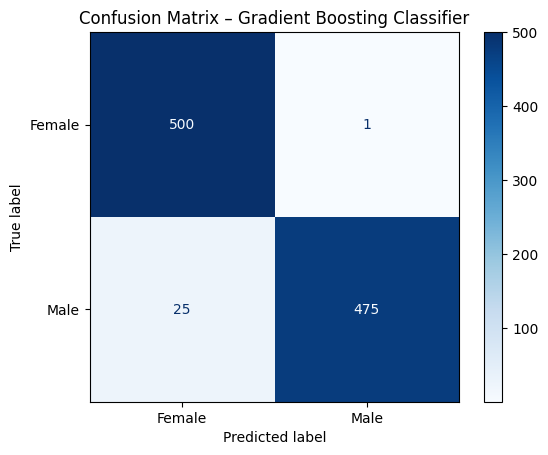

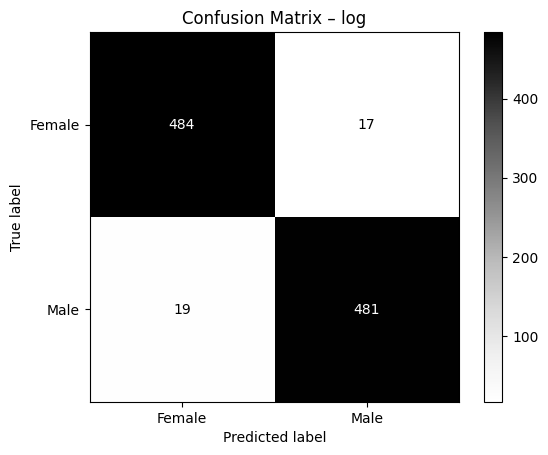

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Gradient Boosting Classifier")
# plt.show()

y_pred = weak_model.predict(X_test)

cm2 = confusion_matrix(y_test, y_pred, labels=weak_model.classes_)

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=weak_model.classes_
)

disp2.plot(cmap="Grays")
plt.title("Confusion Matrix – log")
plt.show()


#Confusion Matrix Analysis & Final Conclusion


---

## Gradient Boosting Classifier

### Confusion Matrix
| True \ Pred | Female | Male |
|------------|--------|------|
| **Female** | 500 | 1 |
| **Male** | 25 | 475 |

### Precision & Recall

**Female class**
- Precision = 500 / (500 + 25) ≈ **0.95**
- Recall = 500 / (500 + 1) ≈ **0.998**

**Male class**
- Precision = 475 / (475 + 1) ≈ **0.998**
- Recall = 475 / (475 + 25) ≈ **0.95**

### Interpretation
The Gradient Boosting model shows excellent performance with very few misclassifications.
- It achieves near-perfect recall for the Female class
- very high precision for both classes.




---

## Logistic Regression

### Confusion Matrix
| True \ Pred | Female | Male |
|------------|--------|------|
| **Female** | 484 | 17 |
| **Male** | 19 | 481 |

### Precision & Recall

**Female class**
- Precision = 484 / (484 + 19) ≈ **0.96**
- Recall = 484 / (484 + 17) ≈ **0.97**

**Male class**
- Precision = 481 / (481 + 17) ≈ **0.97**
- Recall = 481 / (481 + 19) ≈ **0.96**

## Interpretation
Logistic Regression demonstrates more balanced error distribution across both classes.
- However, it produces a higher total number of misclassifications compared to Gradient Boosting
- indicating weaker overall discriminative power.

---

## Final Conclusion

The confusion matrices and derived precision–recall metrics show that **Gradient Boosting outperforms Logistic Regression** in overall classification accuracy. While Logistic Regression exhibits more symmetric errors.  

Based on these results, **Gradient Boosting is selected as the final model**, as it demonstrates superior predictive performance and better handling of complex, non-linear patterns in the data.

---

